## Setup
#### Import libraries

In [1]:
%matplotlib inline

import sys
import numpy as np
import scipy.sparse as ssp
import pandas as pd
import os
import matplotlib.pyplot as plt
#import scrublet as scr
import scanpy as sc
import time
# !!!!
# Change this path to point to folder containing helper_functions.py
sys.path.append('path/to/helper_functions.py')
import helper_functions as hf


#### Set up display parameters for nicer looking plots

In [2]:
hf.set_plot_defaults(fontsize=12)


## Load raw transcriptome data
#### Specify metadata and path to raw data

In [3]:
input_paths = {
    '/Users/ignas/Dropbox (HMS)/HMS_Klein-lab/PhD/Capsules/2024/Drug_memory/2024_10_18_run/Sequencing/Memory_seq_depp/' : [
                                                                                                    'C1_1/C1_1', #Control-1, technical rep1 samples
                                                                                                     'C1_2/C1_2',
                                                                                                     'C1_3/C1_3',
                                                                                                     'C1_4/C1_4',
                                                                                                    'C2_1/C2_1', #Control-1, technical rep2 samples
                                                                                                     'C2_2/C2_2',
                                                                                                     'C2_3/C2_3',
                                                                                                     'C2_4/C2_4',
                                                                                                     'V1_1/V1_1', #Vorinostat, technical rep1 samples
                                                                                                     'V1_2/V1_2',
                                                                                                     'V1_3/V1_3',
                                                                                                     'V1_4/V1_4',
                                                                                                     'V2_1/V2_1', #Vorinostat, technical rep2 samples
                                                                                                     'V2_2/V2_2',
                                                                                                     'V2_3/V2_3',
                                                                                                     'V2_4/V2_4',
                                                                                                     'D2_1/D2_1', #Decitabine, technical rep2 samples
                                                                                                     'D2_2/D2_2',
                                                                                                     'D2_3/D2_3',
                                                                                                     'D2_4/D2_4',
                                                                                                    'D1_1/D1_1', #Decitabine, technical rep1 samples
                                                                                                     'D1_2/D1_2',
                                                                                                     'D1_3/D1_3',
                                                                                                     'D1_4/D1_4',
                                                                                                     'A1_1/A1_1', #5Aza, technical rep1 samples
                                                                                                     'A1_2/A1_2',
                                                                                                     'A1_3/A1_3',
                                                                                                     'A1_4/A1_4',
                                                                                                     'A2_1/A2_1', #5Aza, technical rep2 samples
                                                                                                     'A2_2/A2_2',
                                                                                                     'A2_3/A2_3',
                                                                                                     'A2_4/A2_4',
                                                                                                     'C1a_1/C1a_1', #Control-2, technical rep1 samples
                                                                                                     'C1a_2/C1a_2',
                                                                                                     'C1a_3/C1a_3',
                                                                                                     'C1a_4/C1a_4',
                                                                                                     'C2a_1/C2a_1', #Control-2, technical rep2 samples
                                                                                                     'C2a_2/C2a_2',
                                                                                                     'C2a_3/C2a_3',
                                                                                                     'C2a_4/C2a_4',
                                                                                                     'K1_1/K1_1', #Control-3, technical rep1 samples
                                                                                                     'K1_2/K1_2',
                                                                                                     'K1_3/K1_3',
                                                                                                     'K1_4/K1_4',
                                                                                                     'K2_1/K2_1', #Control-3, technical rep2 samples
                                                                                                     'K2_2/K2_2',
                                                                                                     'K2_3/K2_3',
                                                                                                     'K2_4/K2_4',
 ]}

h5ad_dir = 'h5ad_files'
plot_dir = '_plots'

# `meta_keys` lists the names of the columns to be added to the .obs dataframe.
# For each key in `meta_keys`, there must be a corresponding entry in the 
# `meta_values` list for each sample.
# Use key 'new name' if you want to convert the original sample IDs into more
# meaningful sample names.
meta_keys = ['new name']

meta_values = {}
samps = [s for s in input_paths.values()][0]
for s in samps:
    meta_values[s] = [s.split('/')[0]]


# Set some default filtering parameters. These can be
# customized for each library at a later step.

# min number of UMIs per cell barcode, for separating 
# background from real cells
default_min_tot = 500  

# max fraction of UMIs from mitochondrial genes, for 
# separating live and dead cells
default_max_mito_frac = 0.15 



#### Load raw counts matrices from indrops.py pipeline (.tsv files), saving .h5ad files for faster loading in the future

In [4]:
######

sample_list = []
D = {}
os.makedirs(h5ad_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

for iFold, folder in enumerate(input_paths):
    for orig_name in input_paths[folder]:
        meta_dict = {k: meta_values[orig_name][i] for i,k in enumerate(meta_keys)}
        
        if 'new name' in meta_keys:
            new_name = meta_dict['new name']
        else:
            new_name = orig_name    
        sample_list.append(new_name)
        
        h5ad_filename = f'{h5ad_dir}/{new_name}-raw.h5ad'
        if os.path.exists(h5ad_filename):
            D[new_name] = sc.read(h5ad_filename)
        else:
            X, barcodes, genes = hf.load_annotated_text(
                hf.file_opener(f'{folder}/{orig_name}.counts.tsv.gz'),
                delim='\t',
                read_row_labels=True,
                read_column_labels=True
            )
            D[new_name] = sc.AnnData(X, dtype = 'float64')
            D[new_name].obs_names = barcodes
            D[new_name].var_names = genes
            D[new_name].var_names_make_unique()
            del X, barcodes, genes
                        
            D[new_name].uns['min_tot'] = default_min_tot
            D[new_name].uns['max_mito'] = default_max_mito_frac
            
            
            for k,v in meta_dict.items():
                if k != 'new name':
                    D[new_name].obs[k] = v
                    
            D[new_name].write_h5ad(h5ad_filename, compression='gzip', force_dense=False)

        print('Loaded {}: {} barcodes, {} genes'.format(new_name, *D[new_name].shape))

Loaded C1_1: 23772 barcodes, 86054 genes
Loaded C1_2: 36332 barcodes, 86054 genes
Loaded C1_3: 23174 barcodes, 86054 genes
Loaded C1_4: 11534 barcodes, 86054 genes
Loaded C2_1: 27891 barcodes, 86054 genes
Loaded C2_2: 39855 barcodes, 86054 genes
Loaded C2_3: 21850 barcodes, 86054 genes
Loaded C2_4: 12540 barcodes, 86054 genes
Loaded V1_1: 25916 barcodes, 86054 genes
Loaded V1_2: 28176 barcodes, 86054 genes
Loaded V1_3: 43532 barcodes, 86054 genes
Loaded V1_4: 30045 barcodes, 86054 genes
Loaded V2_1: 28209 barcodes, 86054 genes
Loaded V2_2: 39906 barcodes, 86054 genes
Loaded V2_3: 41051 barcodes, 86054 genes
Loaded V2_4: 36229 barcodes, 86054 genes
Loaded D2_1: 44990 barcodes, 86054 genes
Loaded D2_2: 51498 barcodes, 86054 genes
Loaded D2_3: 44241 barcodes, 86054 genes
Loaded D2_4: 52355 barcodes, 86054 genes
Loaded D1_1: 45534 barcodes, 86054 genes
Loaded D1_2: 54766 barcodes, 86054 genes
Loaded D1_3: 50194 barcodes, 86054 genes
Loaded D1_4: 50580 barcodes, 86054 genes
Loaded A1_1: 525

## Load quant_metric files

In [5]:
# store quant_metrics in the same adict file
input_start = list(input_paths.keys())[0]
input_dirs = [input_start + s +'/' for s in sample_list]


meta_keys = ['new name']
meta_values = {}

for s in samps:
    meta_values[s.split('/')[0]] = [s.split('/')[0]]


for iFold, folder in enumerate(input_dirs):
    for file in os.listdir(folder):
        if file.endswith('metrics.tsv.gz'):

             # Get library ID from file name
            s = file.split('.')[0]

            #if you changed the library name, this will assign the same name
            meta_dict = {k: meta_values[s][i] for i,k in enumerate(meta_keys)}
            if 'new name' in meta_keys:
                s = meta_dict['new name']
            else:
                pass
            
            print('___________________')
            print(s)

            df = (pd.read_csv((folder + '/' + file), delimiter='\t'))
            print(np.array(df.T.iloc[6]))
            #bc_mask = np.array([iG for iG, i in enumerate(df['Barcode'].values) if i in D[s].obs_names.values])
            #df = df.iloc[bc_mask]
            #D[s].obs['Reads'] = np.array(df['Reads'])
            D[s].obs['Reads'] = np.array(df.T.iloc[1])
            D[s].obs['Unique'] = np.array(df.T.iloc[2])
            D[s].obs['Unique%'] = np.array(np.array(df.T.iloc[2])/np.array(df.T.iloc[1]) *100)
            D[s].obs['Mapped_Reads'] = np.array(np.array(df.T.iloc[1]) - np.array(df.T.iloc[6]))
            D[s].obs['% reads mapped'] = np.array(((np.array(df.T.iloc[1]) - np.array(df.T.iloc[6]))/np.array(df.T.iloc[1])) *100)          

for iFold, folder in enumerate(input_dirs):
    for file in os.listdir(folder):
        if file.endswith('stats.csv'): 
            
            # Get library ID from file name
            s = file.split('.')[0]
            meta_dict = {k: meta_values[s][i] for i,k in enumerate(meta_keys)}
            if 'new name' in meta_keys:
                s = meta_dict['new name']

            df = (pd.read_csv((folder + '/' + file)))
            D[s].uns['Input_Reads'] = np.array(df['Input Reads'].sum())
            D[s].uns['Valid_Reads'] = np.array(df['Valid Structure'].sum())
            

___________________
C1_1
[261639 1582 429 ... 580 393 314]
___________________
C1_2
[183800 1122 506 ... 204 203 215]
___________________
C1_3
[823644 1193 661 ... 779 519 245]
___________________
C1_4
[1714572 1308 298 ... 370 1419 295]
___________________
C2_1
[282357 2093 539 ... 418 319 228]
___________________
C2_2
[330027 896 430 ... 256 293 230]
___________________
C2_3
[1529754 1496 669 ... 742 489 255]
___________________
C2_4
[3340030 1933 479 ... 363 1886 430]
___________________
V1_1
[295060 3366 737 ... 453 322 279]
___________________
V1_2
[611399 2095 1048 ... 603 405 243]
___________________
V1_3
[327280 1813 1095 ... 404 241 283]
___________________
V1_4
[501645 1377 869 ... 422 234 250]
___________________
V2_1
[283579 3031 658 ... 400 276 247]
___________________
V2_2
[567898 1829 926 ... 477 329 293]
___________________
V2_3
[1148663 2085 1141 ... 434 320 316]
___________________
V2_4
[547400 1689 1091 ... 475 296 299]
___________________
D2_1
[1770492 3319 1387 ...

In [6]:
import pickle
for s in sample_list:
    D[f'{s}'].obs['barcode'] = D[f'{s}'].obs_names

for s in sample_list:
    abundant_barcodes = pickle.load( open( input_start + s + '/abundant_barcodes.pickle', "rb" ) )
    
    bc_converter = {}
    for bc,name in abundant_barcodes.items():
        
        
        bc_converter[name[0]] = bc
    
    bc_new = []
    for barcode in D[f'{s}'].obs['barcode'].values:
        bc_new.append(bc_converter[barcode])
    D[f'{s}'].obs['barcode_seq'] = bc_new


In [7]:
stats = {}
for iFold, folder in enumerate(input_dirs):
    for file in os.listdir(folder):
        if file.endswith('stats.csv'): 
            
            # Get library ID from file name
            s = file.split('.')[0]
            meta_dict = {k: meta_values[s][i] for i,k in enumerate(meta_keys)}
            if 'new name' in meta_keys:
                s = meta_dict['new name']

            df = (pd.read_csv((folder + '/' + file)))
            a = np.array(df['Input Reads'].sum())
            b = np.array(df['Valid Structure'].sum())
            c = np.array(df['Invalid BC1'].sum())
            d = np.array(df['Invalid BC2'].sum())
            stats[s] = pd.DataFrame(np.array([a,b,c,d])).T
            stats[s].columns = ['Input Reads', 'Valid Structure', 'Invalid BC1', 'Invalid BC2']

In [8]:
saving = True

# Change total count thresholds based on the histograms. 
# If a library is not included below, the default threshold is used.
#Smart-seq
ct = 2e3

D['C1_1'].uns['min_tot'] =ct
D['C1_2'].uns['min_tot'] =ct
D['C1_3'].uns['min_tot'] =ct
D['C1_4'].uns['min_tot'] =ct
D['V1_1'].uns['min_tot'] =ct
D['V1_2'].uns['min_tot'] =ct
D['V1_3'].uns['min_tot'] =ct
D['V1_4'].uns['min_tot'] =ct
D['C2_1'].uns['min_tot'] =ct
D['C2_2'].uns['min_tot'] =ct
D['C2_3'].uns['min_tot'] =ct
D['C2_4'].uns['min_tot'] =ct
D['V2_1'].uns['min_tot'] =ct
D['V2_2'].uns['min_tot'] =ct
D['V2_3'].uns['min_tot'] =ct
D['V2_4'].uns['min_tot'] =ct
D['D1_1'].uns['min_tot'] =ct
D['D1_2'].uns['min_tot'] =ct
D['D1_3'].uns['min_tot'] =ct
D['D1_4'].uns['min_tot'] =ct
D['A1_1'].uns['min_tot'] =ct
D['A1_2'].uns['min_tot'] =ct
D['A1_3'].uns['min_tot'] =ct
D['A1_4'].uns['min_tot'] =ct
D['D2_1'].uns['min_tot'] =ct
D['D2_2'].uns['min_tot'] =ct
D['D2_3'].uns['min_tot'] =ct
D['D2_4'].uns['min_tot'] =ct
D['A2_1'].uns['min_tot'] =ct
D['A2_2'].uns['min_tot'] =ct
D['A2_3'].uns['min_tot'] =ct
D['A2_4'].uns['min_tot'] =ct
D['C1a_1'].uns['min_tot'] =ct
D['C1a_2'].uns['min_tot'] =ct
D['C1a_3'].uns['min_tot'] =ct
D['C1a_4'].uns['min_tot'] =ct
D['K1_1'].uns['min_tot'] =ct
D['K1_2'].uns['min_tot'] =ct
D['K1_3'].uns['min_tot'] =ct
D['K1_4'].uns['min_tot'] =ct
D['C2a_1'].uns['min_tot'] =ct
D['C2a_2'].uns['min_tot'] =ct
D['C2a_3'].uns['min_tot'] =ct
D['C2a_4'].uns['min_tot'] =ct
D['K2_1'].uns['min_tot'] =ct
D['K2_2'].uns['min_tot'] =ct
D['K2_3'].uns['min_tot'] =ct
D['K2_4'].uns['min_tot'] =ct
############

# Start figure
fig, nrow, ncol = hf.start_subplot_figure(len(sample_list), row_height=3, n_columns=4, fig_width=16, dpi=300)

for iS,s in enumerate(sample_list):
    # Loop over each library, plotting histogram of total counts (UMIs) per cell
    
    # Set subplot
    ax = plt.subplot(nrow, ncol, iS+1)
    
    # Calculate total counts per cells (row sums of counts matrix)
    D[s].obs['n_counts'] = D[s].X.sum(1).A.squeeze()
    
    # Get minimum total counts threshold. Barcodes with 
    # total counts >= min_tot are considered real cells. 
    min_tot = D[s].uns['min_tot']
    
    # Plot the histogram
    hf.total_counts_histogram(D[s].obs['n_counts'],n_bins=100, min_bin=10, max_bin=3e4, ax=ax, counts_per_bin=False)
    ax.set_title(s, fontsize=12)
    
    xl = np.array(ax.get_xlim())
    yl = np.array(ax.get_ylim())
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    
    # Plot the threshold    
    ax.plot(min_tot * np.ones(2), yl, c=.7*np.ones(3), linewidth=1)
    
    # Calculate number of barcodes and pct of UMIs passing filter and show on plot
    mask = D[s].obs['n_counts'].values >= min_tot
    ntot = D[s].shape[0]
    npass = mask.sum()
    umitot = D[s].obs['n_counts'].values.sum()
    umipass = D[s].obs['n_counts'].values[mask].sum()
    
    ax.text(xl[0] + 10**(np.log10(xl.ptp())*0.05), yl[0] + yl.ptp() * 0.88, '{} cells'.format(npass), fontsize=12)
    ax.text(xl[0] + 10**(np.log10(xl.ptp())*0.05), yl[0] + yl.ptp() * 0.77, '{:.1f}% of UMIs'.format(umipass/umitot*100), fontsize=12)
    
fig.tight_layout()

#if saving:
#    plt.savefig(f'{plot_dir}/background_filtering.pdf')


## Filter out background based on UMIs/cell
#### First, plot histograms and customize filtering thresholds
No filtering is actually done here, just checking that the total UMIs threshold is appropriate for each library. The threshold should lie between the two modes of the histogram, where the left mode corresponds to background and the right to real cells. Also check that (roughly) the expected number of cells are passing the filter.

#### Pre-filter statistics in DataFrame

In [9]:
df = pd.DataFrame()
df2 = pd.DataFrame()
for iS, s in enumerate(sample_list):
    f = D[s].obs['Reads'].sum() 
    f1 = D[s].obs['Reads'].mean() 
    e = D[s].obs['n_counts'].sum()
    d = D[s].obs['n_counts'].mean()
    a = D[s].obs['% reads mapped'].mean()
    b = (D[s].obs['n_counts'].sum() / D[s].obs['Reads'].sum())
    g = [[f, f1, e, d, a, b]]
    df = pd.concat([df, pd.DataFrame(g, index = [s], columns = ['Reads',
                                                                'Reads/Cell',
                                                                'UMI',
                                                                'UMIs/Cell',
                                                                '% Mean Reads Mapped',
                                                                'UMI/Read'])])



In [10]:
print('{:20s}{:>25s}{:>25s}'.format('Sample', '# barcodes pre-filter', '# barcodes post-filter'))

for s in sample_list:
    keep = D[s].obs['n_counts'] >= D[s].uns['min_tot']
    D[s] = D[s][keep].copy()
    
    n_orig = len(keep)
    n_pass = keep.sum()
    print('{:20s}{:>25}{:>25}'.format(s, n_orig, n_pass))
    
        #Store the data in dataframe
    a = n_orig 
    g = [[a]]
    df2 = pd.concat([df2, pd.DataFrame(g, index = [s], columns = ['Barcodes pre-filter'])])
df = pd.concat([df, df2], axis = 1)

Sample                  # barcodes pre-filter   # barcodes post-filter
C1_1                                    23772                     3919
C1_2                                    36332                     2875
C1_3                                    23174                      926
C1_4                                    11534                      867
C2_1                                    27891                     4292
C2_2                                    39855                     2660
C2_3                                    21850                     1004
C2_4                                    12540                     1054
V1_1                                    25916                     4936
V1_2                                    28176                     2310
V1_3                                    43532                     1980
V1_4                                    30045                     2194
V2_1                                    28209                     4776
V2_2  

## Filter out dead cells based on mitochondrial gene fraction
#### Find mitochondrial genes (for mouse: all genes starting with "mt-")

In [14]:
for iS,s in enumerate(sample_list):
    mt_ix = np.array([i for i,g in enumerate(D[s].var_names) if (g.startswith('mt-') or g.startswith('MT-'))], dtype=int)
    #print(D[s].var_names[mt_ix])

In [15]:
for iS,s in enumerate(sample_list):
    # Loop over each library, plotting histogram of fraction of UMIs
    # coming from mitochondrial genes.
    mt_ix = np.array([i for i,g in enumerate(D[s].var_names) if (g.startswith('mt-') or g.startswith('MT-'))], dtype=int)
    max_mt = 0.5
    D[s].obs['mito_frac'] = D[s].X[:,mt_ix].sum(1).A.squeeze() / D[s].obs['n_counts'].values
    

<Figure size 600x5400 with 0 Axes>

#### Now actually remove barcodes with too many mitochondrial gene counts

In [16]:
print('{:20s}{:>25s}{:>25s}'.format('Sample', '# barcodes pre-filter', '# barcodes post-filter'))

for s in sample_list:
    #max_mt = 0.
    keep = D[s].obs['mito_frac'] <= max_mt
    D[s] = D[s][keep].copy()
    
    n_orig = len(keep)
    n_pass = keep.sum()
    print('{:20s}{:>25}{:>25}'.format(s, n_orig, n_pass))


Sample                  # barcodes pre-filter   # barcodes post-filter
C1_1                                     3919                     3107
C1_2                                     2875                     2762
C1_3                                      926                      918
C1_4                                      867                      865
C2_1                                     4292                     3257
C2_2                                     2660                     2511
C2_3                                     1004                      998
C2_4                                     1054                     1047
V1_1                                     4936                     4854
V1_2                                     2310                     2277
V1_3                                     1980                     1970
V1_4                                     2194                     2176
V2_1                                     4776                     4681
V2_2  

## Summary stats

In [17]:
print('{:20s}{:>5s}{:>16s}{:>16s}{:>16s}{:>16s}'.format(
    'Library', 'N', 'Mean UMI', 'Median UMI', 'Mean Genes', 'Median Genes'))

for s in sample_list:
    tc = D[s].obs['n_counts'].values
    tg = (D[s].X>0).sum(1).A.squeeze()
    print(f'{s:20s}{D[s].shape[0]:5}{np.mean(tc):16.0f}{np.median(tc):16.0f}{np.mean(tg):16.0f}{np.median(tg):16.0f}')

Library                 N        Mean UMI      Median UMI      Mean Genes    Median Genes
C1_1                 3107            8263            5018            1825            1311
C1_2                 2762           15887           10459            4262            3909
C1_3                  918           31512           11633            5532            4306
C1_4                  865           18529            3131            2142            1151
C2_1                 3257            8763            5324            1851            1357
C2_2                 2511           19389           10828            4499            3901
C2_3                  998           30009            6846            5029            3030
C2_4                 1047           16648            3011            1996            1058
V1_1                 4854            7377            5126            2222            1770
V1_2                 2277           15557            8837            4172            3456
V1_3      

## Plot post-filter reads mapped

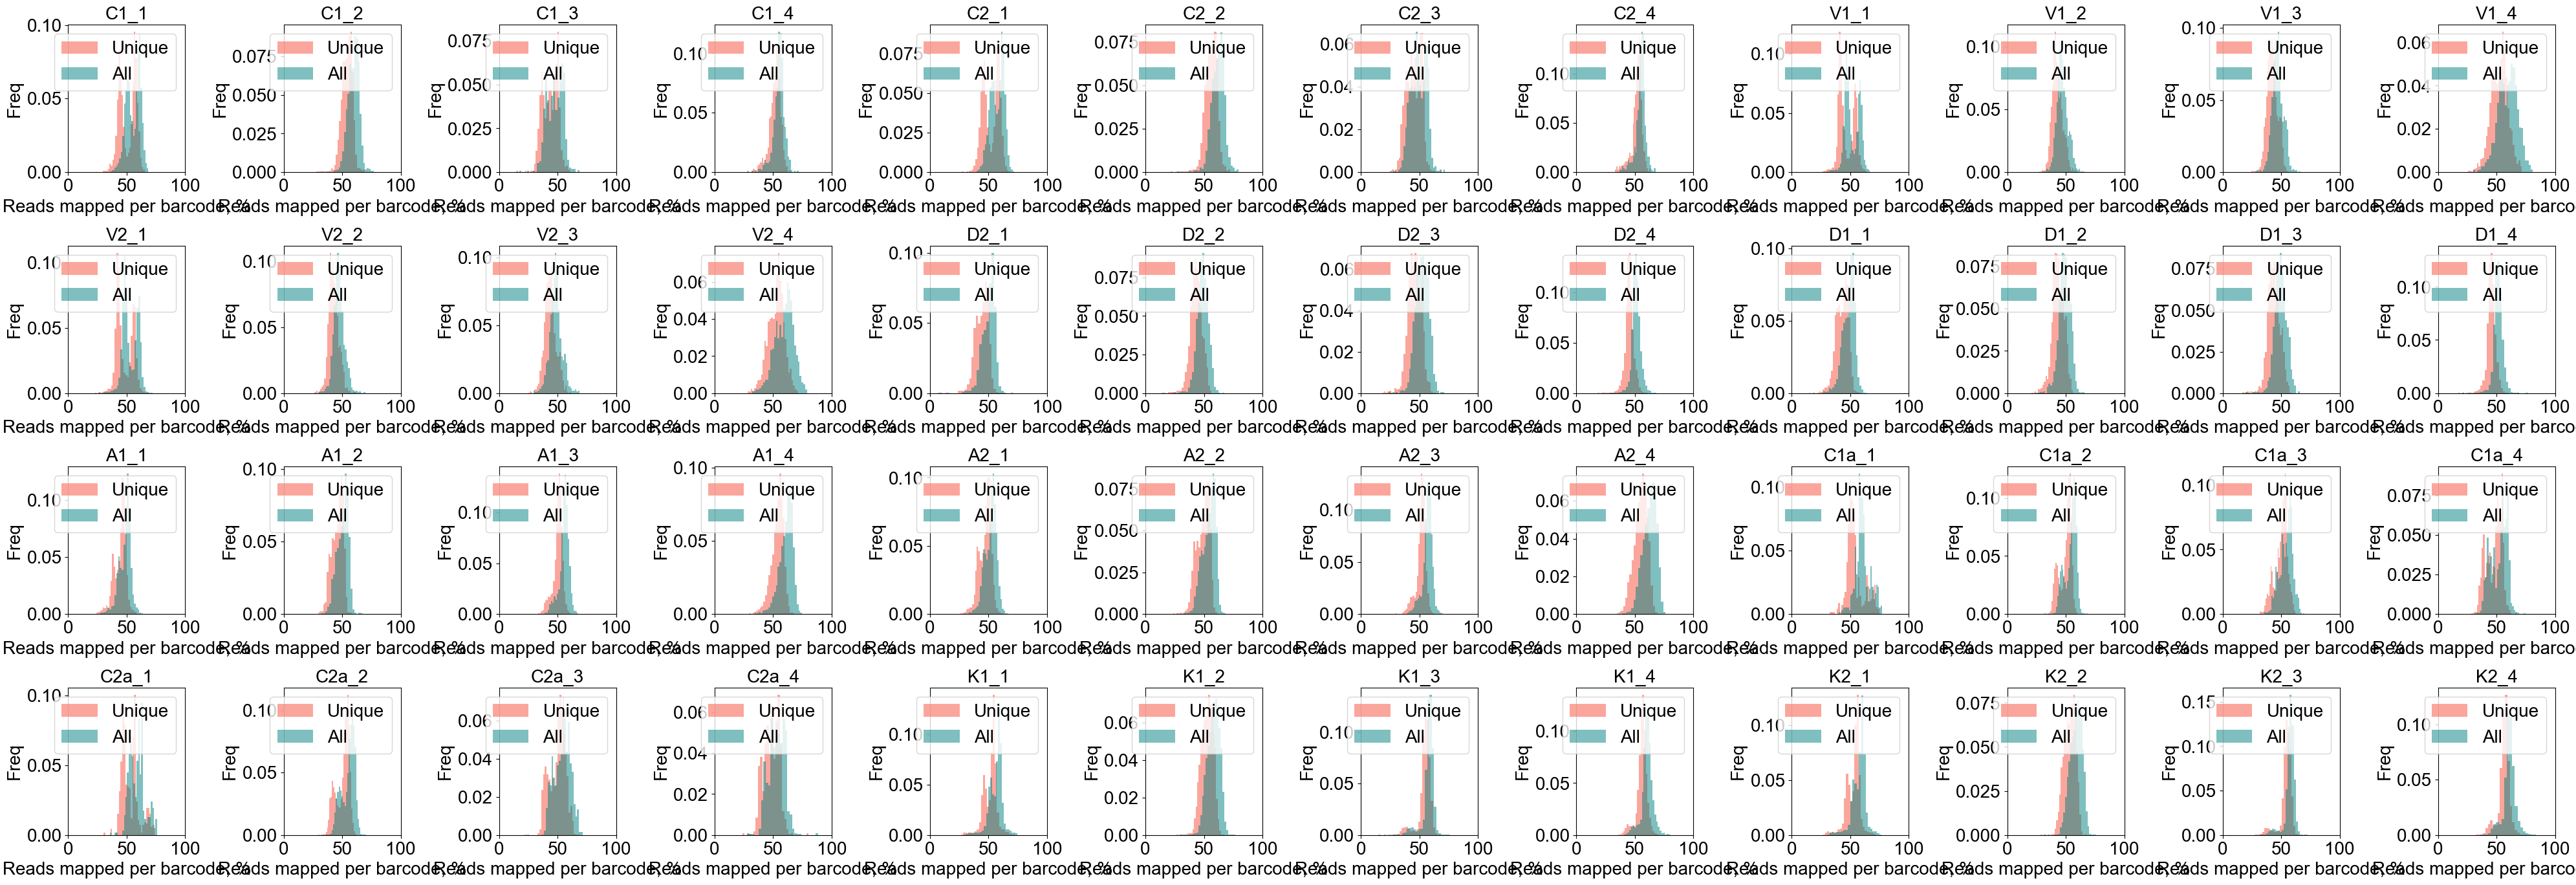

In [18]:
%matplotlib inline
fig = plt.figure(figsize = (40, 20))
#fig.suptitle('% Reads mapped post-filter', fontsize=25, x=0.26, y=1.1)

for iS, s in enumerate(sample_list):
    ax = plt.subplot(6,12, iS+1)
    ax.grid(False)
    ax.set_xlim(0, 100)
    
    ax.hist(D[s].obs['Unique%'], bins = 30, density = True, alpha = 0.7, color = 'salmon', label='Unique')

    ax.hist(D[s].obs['% reads mapped'], bins = 30, density = True, alpha = 0.5, color = 'teal', label='All')
    ax.set_title(s, fontsize = 20)

    ax.legend(fontsize = 20)
    ax.set_xlabel('Reads mapped per barcode, %', fontsize=20)
    ax.set_ylabel('Freq', fontsize=20)
    ax.tick_params(labelsize = 20)

fig.tight_layout()
#fig.savefig('%_Reads_mapped_post-filter.png', dpi = 100, bbox_inches='tight')

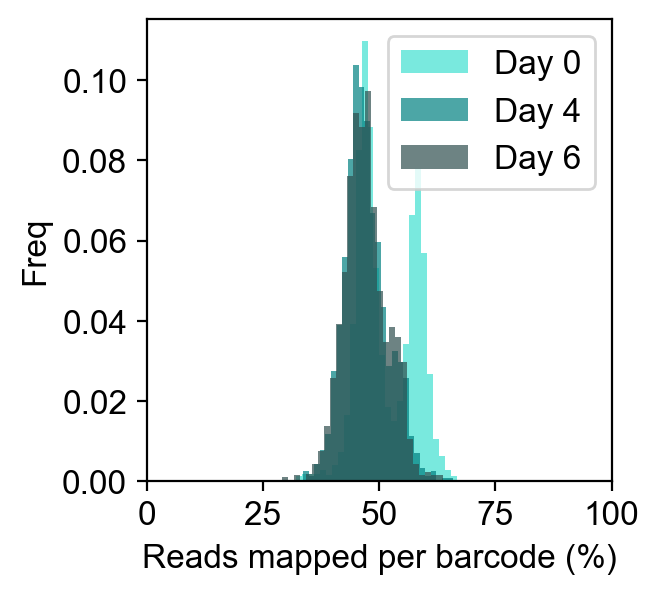

In [19]:
fig, ax = plt.subplots(figsize = (3,3), dpi = 200)
ax.hist(D['V1_1'].obs['% reads mapped'], bins = 30, density = True, alpha = 0.7, color = 'turquoise', label='Day 0')
ax.hist(D['V1_2'].obs['% reads mapped'], bins = 30, density = True, alpha = 0.7, color = 'teal', label='Day 4')
ax.hist(D['V1_3'].obs['% reads mapped'], bins = 30, density = True, alpha = 0.7, color = 'darkslategray', label='Day 6')
ax.set_xlabel('Reads mapped per barcode (%)', fontsize=12)
ax.set_ylabel('Freq', fontsize=12)
ax.set_xlim(0, 100)
ax.legend()

## Combined plot for specific samples

## Add post-filtering statistics to the Dataframe

In [20]:
df2 = pd.DataFrame()
for iS, s in enumerate(sample_list):
    in1 = D[s].uns['Input_Reads']
    in2 = D[s].uns['Valid_Reads']
    f = D[s].obs['Reads'].sum() 
    f1 = D[s].obs['Reads'].mean() 
    e = D[s].obs['n_counts'].sum()
    d = D[s].obs['n_counts'].mean()
    a = D[s].obs['% reads mapped'].mean()
    b = (D[s].obs['n_counts'].sum()/D[s].obs['Reads'].sum())
    g = [[in1, in2, f, f1, e, d, a, b]]
    df2 = pd.concat([df2, pd.DataFrame(g, index = [s], columns = ['Input_Reads',
                                                                  'Valid_Reads',
                                                                'Reads PF',
                                                                  'Reads/Cell PF',
                                                                  'UMI PF','UMIs/Cell PF',
                                                                  '% Mean Reads Mapped PF',
                                                                  'UMI/Read PF'])])
df = pd.concat([df, df2], axis = 1)

In [21]:
#Mask for mouse genes in the matrix
mouse_mask = []
for g in D['V1_1'].var_names.values:
    if g[-2:] == 'mm':
        mouse_mask.append(1)
    else:
        mouse_mask.append(0)
mouse_mask = np.array(mouse_mask)


In [22]:
#Split the datasets into mouse and human samples
D_cells = {}
for s in sample_list:
    x = D[s].X.A.T[mouse_mask==1].sum(0)
    y = D[s].X.A.T[mouse_mask==0].sum(0)
    D_cells[s+'_k562'] = D[s][y>3*x, mouse_mask == 0].copy()
    D_cells[s+'_l1210'] = D[s][x>3*y, mouse_mask == 1].copy()

In [23]:
import re
# Filter gene set to remove several uninteresting classes of genes
genes_to_use_mouse = D_cells['C1_1_l1210'].var_names
genes_to_use_human = D_cells['C1_1_k562'].var_names
override_filter = False
def mask_genes(genes_to_use):
    # Filter out genes
    #.   that start with 'mt-' , AC, AB, AI, AA
    genes_to_use = [gene for gene in genes_to_use if not gene.upper().startswith('MT-')]
    genes_to_use = [gene for gene in genes_to_use if not gene.upper().startswith('MIR')]
    genes_to_use = [gene for gene in genes_to_use if not gene.upper().startswith('MALAT')]
    genes_to_use = [gene for gene in genes_to_use if not re.match(r'^AA\d', gene)]
    genes_to_use = [gene for gene in genes_to_use if not re.match(r'^AC\d', gene)]
    genes_to_use = [gene for gene in genes_to_use if not re.match(r'^AI\d', gene)]
    genes_to_use = [gene for gene in genes_to_use if not re.match(r'^AU\d', gene)]
    #.   or start with 'Gm' followed by a digit
    genes_to_use = [gene for gene in genes_to_use if not re.match(r'^GM\d', gene.upper())]
    #.   or end with 'Rik' followed by a digit
    genes_to_use = [gene for gene in genes_to_use if not gene.upper().endswith('RIK')]
    #.   or start with 'RPS' followed by a digit
    #genes_to_use = [gene for gene in genes_to_use if not re.match(r'^RPS\d', gene.upper())]
    #.   or start with 'RPL' followed by a digit
    #genes_to_use = [gene for gene in genes_to_use if not re.match(r'^RPL\d', gene.upper())]
    genes_to_use = [gene for gene in genes_to_use if not gene.upper().startswith('CT010467')]
    #genes_to_use = [gene for gene in genes_to_use if not gene.upper().startswith('RPL')]
    #genes_to_use = [gene for gene in genes_to_use if not gene.upper().startswith('RPS')]
    
    return genes_to_use

genes_to_use_mouse = mask_genes(genes_to_use_mouse)
genes_to_use_human = mask_genes(genes_to_use_human)

### Manually generate sample labels

In [24]:
for s in sample_list:
    D_cells[s+'_l1210'] = D_cells[s+'_l1210'][:, genes_to_use_mouse].copy()
    D_cells[s+'_k562'] = D_cells[s+'_k562'][:, genes_to_use_human].copy()

In [25]:
#Concatinate replicates
for line in ['l1210', 'k562']:
    D_cells['C_1'+ '_'+  line] = sc.concat([D_cells['C1_1'+ '_' + line], D_cells['C2_1'+ '_' + line]])
    D_cells['C_2'+ '_' + line] = sc.concat([D_cells['C1_2'+ '_' + line], D_cells['C2_2'+ '_' + line]])
    D_cells['C_3'+ '_' + line] = sc.concat([D_cells['C1_3'+ '_' + line], D_cells['C2_3'+ '_' + line]])
    D_cells['C_4'+ '_' + line] = sc.concat([D_cells['C1_4'+ '_' + line], D_cells['C2_4'+ '_' + line]])
    
    D_cells['K_1'+ '_'+  line] = sc.concat([D_cells['K1_1'+ '_' + line], D_cells['K2_1'+ '_' + line]])
    D_cells['K_2'+ '_' + line] = sc.concat([D_cells['K1_2'+ '_' + line], D_cells['K2_2'+ '_' + line]])
    D_cells['K_3'+ '_' + line] = sc.concat([D_cells['K1_3'+ '_' + line], D_cells['K2_3'+ '_' + line]])
    D_cells['K_4'+ '_' + line] = sc.concat([D_cells['K1_4'+ '_' + line], D_cells['K2_4'+ '_' + line]])
    
    D_cells['Ca_1'+ '_'+  line] = sc.concat([D_cells['C1a_1'+ '_' + line], D_cells['C2a_1'+ '_' + line]])
    D_cells['Ca_2'+ '_' + line] = sc.concat([D_cells['C1a_2'+ '_' + line], D_cells['C2a_2'+ '_' + line]])
    D_cells['Ca_3'+ '_' + line] = sc.concat([D_cells['C1a_3'+ '_' + line], D_cells['C2a_3'+ '_' + line]])
    D_cells['Ca_4'+ '_' + line] = sc.concat([D_cells['C1a_4'+ '_' + line], D_cells['C2a_4'+ '_' + line]])
    
    D_cells['V_1'+ '_'+  line] = sc.concat([D_cells['V1_1'+ '_' + line], D_cells['V2_1'+ '_' + line]])
    D_cells['V_2'+ '_' + line] = sc.concat([D_cells['V1_2'+ '_' + line], D_cells['V2_2'+ '_' + line]])
    D_cells['V_3'+ '_' + line] = sc.concat([D_cells['V1_3'+ '_' + line], D_cells['V2_3'+ '_' + line]])
    D_cells['V_4'+ '_' + line] = sc.concat([D_cells['V1_4'+ '_' + line], D_cells['V2_4'+ '_' + line]])
    
    D_cells['A_1'+ '_'+  line] = sc.concat([D_cells['A1_1'+ '_' + line], D_cells['A2_1'+ '_' + line]])
    D_cells['A_2'+ '_' + line] = sc.concat([D_cells['A1_2'+ '_' + line], D_cells['A2_2'+ '_' + line]])
    D_cells['A_3'+ '_' + line] = sc.concat([D_cells['A1_3'+ '_' + line], D_cells['A2_3'+ '_' + line]])
    D_cells['A_4'+ '_' + line] = sc.concat([D_cells['A1_4'+ '_' + line], D_cells['A2_4'+ '_' + line]])
     
    D_cells['D_1'+ '_'+  line] = sc.concat([D_cells['D1_1'+ '_' + line], D_cells['D2_1'+ '_' + line]])
    D_cells['D_2'+ '_' + line] = sc.concat([D_cells['D1_2'+ '_' + line], D_cells['D2_2'+ '_' + line]])
    D_cells['D_3'+ '_' + line] = sc.concat([D_cells['D1_3'+ '_' + line], D_cells['D2_3'+ '_' + line]])
    D_cells['D_4'+ '_' + line] = sc.concat([D_cells['D1_4'+ '_' + line], D_cells['D2_4'+ '_' + line]])

/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_m

In [26]:
samples = ['C_1_l1210', 'C_2_l1210', 'C_3_l1210', 'C_4_l1210',
           'V_1_l1210', 'V_2_l1210', 'V_3_l1210', 'V_4_l1210',
           'A_1_l1210', 'C_2_l1210', 'C_3_l1210', 'C_4_l1210',
           'D_1_l1210', 'V_2_l1210', 'V_3_l1210', 'V_4_l1210',
           'C_1_k562', 'C_2_k562', 'C_3_k562', 'C_4_k562',
           'V_1_k562', 'V_2_k562', 'V_3_k562', 'V_4_k562',
           'D_1_k562', 'D_2_k562', 'D_3_k562', 'D_4_k562',
           'A_1_k562', 'A_2_k562', 'A_3_k562', 'A_4_k562']

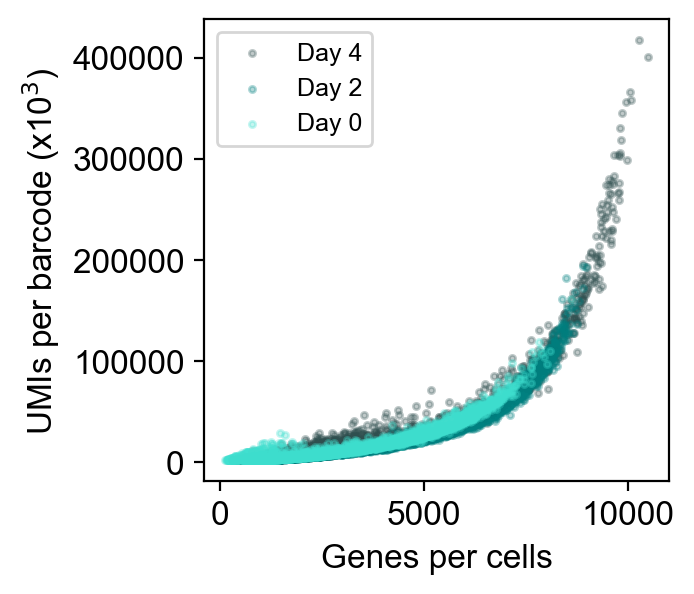

In [27]:
fig, ax = plt.subplots(figsize = (3,3), dpi = 200)


ax.scatter((D_cells['K_3_l1210'].X.A >0).sum(1),D_cells['K_3_l1210'].obs['n_counts'].values, s= 5, c='darkslategray', alpha = 0.3, label = 'Day 4')
ax.scatter((D_cells['K_2_l1210'].X.A >0).sum(1),D_cells['K_2_l1210'].obs['n_counts'].values, s= 5, c='teal',alpha = 0.3, label = 'Day 2') 
ax.scatter((D_cells['K_1_l1210'].X.A >0).sum(1),D_cells['K_1_l1210'].obs['n_counts'].values, s= 5, c='turquoise',alpha = 0.3, label ='Day 0')
ax.set_xlabel('Genes per cells')
ax.set_ylabel('UMIs per barcode (x10$^3$)')

ax.legend(fontsize = 9)


In [36]:
cell_num = {}
n = 0
for samp in D_cells:
    print(samp, D_cells[samp].shape[0], 'cells')
    n+= D_cells[samp].shape[0]

C1_1_k562 1303 cells
C1_1_l1210 1515 cells
C1_2_k562 1101 cells
C1_2_l1210 1541 cells
C1_3_k562 287 cells
C1_3_l1210 506 cells
C1_4_k562 31 cells
C1_4_l1210 798 cells
C2_1_k562 1296 cells
C2_1_l1210 1576 cells
C2_2_k562 916 cells
C2_2_l1210 1443 cells
C2_3_k562 279 cells
C2_3_l1210 532 cells
C2_4_k562 51 cells
C2_4_l1210 968 cells
V1_1_k562 2284 cells
V1_1_l1210 1870 cells
V1_2_k562 1080 cells
V1_2_l1210 852 cells
V1_3_k562 890 cells
V1_3_l1210 577 cells
V1_4_k562 772 cells
V1_4_l1210 482 cells
V2_1_k562 2174 cells
V2_1_l1210 1780 cells
V2_2_k562 964 cells
V2_2_l1210 679 cells
V2_3_k562 831 cells
V2_3_l1210 598 cells
V2_4_k562 701 cells
V2_4_l1210 487 cells
D2_1_k562 588 cells
D2_1_l1210 2364 cells
D2_2_k562 811 cells
D2_2_l1210 1230 cells
D2_3_k562 711 cells
D2_3_l1210 987 cells
D2_4_k562 392 cells
D2_4_l1210 2847 cells
D1_1_k562 610 cells
D1_1_l1210 2050 cells
D1_2_k562 679 cells
D1_2_l1210 1222 cells
D1_3_k562 705 cells
D1_3_l1210 999 cells
D1_4_k562 269 cells
D1_4_l1210 3011 cells


In [30]:

samps_merge_dict = {
    'Vor':   ['V_1_k562','V_2_k562', 'V_3_k562', 'V_4_k562'],
    'Dec':   ['D_1_k562','D_2_k562', 'D_3_k562', 'D_4_k562'],
    'Aza':   ['A_1_k562','A_2_k562', 'A_3_k562', 'A_4_k562'],
    'Ctrl1': ['C_1_k562','C_2_k562', 'C_3_k562', 'C_4_k562'],
    'Ctrl2': ['K_1_k562','K_2_k562', 'K_3_k562', 'K_4_k562'],
    'Ctrl3':['Ca_1_k562','Ca_2_k562', 'Ca_3_k562', 'Ca_4_k562'],
    
    
}
days = ['day0', 'day2', 'day4', 'day6']

D_k562 = {}

for s, samps_merge in samps_merge_dict.items():
    print(f'___________________\nProcessing {s}')
    D_k562[s] = sc.AnnData.concatenate(
        *[D_cells[s] for s in samps_merge], 
        batch_categories=days,
        batch_key='timepoint',
    )
    D_k562[s].obs_names_make_unique()


___________________
Processing Vor
___________________
Processing Dec


/var/folders/xk/8j_p5ynd0034x23z5b59nccr0000gq/T/ipykernel_56494/1047938504.py:17: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  D_k562[s] = sc.AnnData.concatenate(
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/pyt

___________________
Processing Aza
___________________
Processing Ctrl1


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_m

___________________
Processing Ctrl2
___________________
Processing Ctrl3


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_m

In [31]:
samps_merge_dict = {
    'Vor':  ['V_1_l1210','V_2_l1210', 'V_3_l1210', 'V_4_l1210'],
    'Dec':  ['D_1_l1210','D_2_l1210', 'D_3_l1210', 'D_4_l1210'],
    'Aza':  ['A_1_l1210','A_2_l1210', 'A_3_l1210', 'A_4_l1210'],
    'Ctrl1':['C_1_l1210','C_2_l1210', 'C_3_l1210', 'C_4_l1210'],
    'Ctrl2':['K_1_l1210','K_2_l1210', 'K_3_l1210', 'K_4_l1210'],
    'Ctrl3':['Ca_1_l1210','Ca_2_l1210', 'Ca_3_l1210', 'Ca_4_l1210'],
    
    
}


D_l1210 = {}

for s, samps_merge in samps_merge_dict.items():
    print(f'___________________\nProcessing {s}')
    D_l1210[s] = sc.AnnData.concatenate(
        *[D_cells[s] for s in samps_merge], 
        batch_categories=days,
        batch_key='timepoint',
    )
    D_l1210[s].obs_names_make_unique()


___________________
Processing Vor


/var/folders/xk/8j_p5ynd0034x23z5b59nccr0000gq/T/ipykernel_56494/2021355296.py:17: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  D_l1210[s] = sc.AnnData.concatenate(
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/py

___________________
Processing Dec


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_m

___________________
Processing Aza


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_m

___________________
Processing Ctrl1
___________________
Processing Ctrl2


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/xk/8j_p5ynd0034x23z5b59nccr0000gq/T/ipykernel_56494/2021355296.py:17: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  D_l1210[s] = sc.AnnData.concatenate(
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/py

___________________
Processing Ctrl3


/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_m

In [32]:
#Fix datatype in the obs before saving
for s in ['Vor', 'Aza', 'Dec', 'Ctrl1', 'Ctrl2', 'Ctrl3']:
    for o in ['Reads', 'Unique', 'Unique%', 'Mapped_Reads', '% reads mapped', 'n_counts', 'mito_frac']:
        D_l1210[s].obs[o] = D_l1210[s].obs[o].astype(float)
        D_k562[s].obs[o] = D_k562[s].obs[o].astype(float)




In [33]:
D_k562

{'Vor': AnnData object with n_obs × n_vars = 9696 × 32729
     obs: 'Reads', 'Unique', 'Unique%', 'Mapped_Reads', '% reads mapped', 'barcode', 'barcode_seq', 'n_counts', 'mito_frac', 'timepoint',
 'Dec': AnnData object with n_obs × n_vars = 4765 × 32729
     obs: 'Reads', 'Unique', 'Unique%', 'Mapped_Reads', '% reads mapped', 'barcode', 'barcode_seq', 'n_counts', 'mito_frac', 'timepoint',
 'Aza': AnnData object with n_obs × n_vars = 3518 × 32729
     obs: 'Reads', 'Unique', 'Unique%', 'Mapped_Reads', '% reads mapped', 'barcode', 'barcode_seq', 'n_counts', 'mito_frac', 'timepoint',
 'Ctrl1': AnnData object with n_obs × n_vars = 5264 × 32729
     obs: 'Reads', 'Unique', 'Unique%', 'Mapped_Reads', '% reads mapped', 'barcode', 'barcode_seq', 'n_counts', 'mito_frac', 'timepoint',
 'Ctrl2': AnnData object with n_obs × n_vars = 6381 × 32729
     obs: 'Reads', 'Unique', 'Unique%', 'Mapped_Reads', '% reads mapped', 'barcode', 'barcode_seq', 'n_counts', 'mito_frac', 'timepoint',
 'Ctrl3': AnnDat

In [38]:
#Save data for later processing

D_l1210['Vor'].write_h5ad('l1210_Vor.h5ad')
D_l1210['Aza'].write_h5ad('l1210_Aza.h5ad')
D_l1210['Dec'].write_h5ad('l1210_Dec.h5ad')
D_l1210['Ctrl1'].write_h5ad('l1210_Ctrl1.h5ad')
D_l1210['Ctrl2'].write_h5ad('l1210_Ctrl2.h5ad')
D_l1210['Ctrl3'].write_h5ad('l1210_Ctrl3.h5ad')


D_k562['Vor'].write_h5ad('k562_Vor.h5ad')
D_k562['Aza'].write_h5ad('k562_Aza.h5ad')
D_k562['Dec'].write_h5ad('k562_Dec.h5ad')
D_k562['Ctrl1'].write_h5ad('k562_Ctrl1.h5ad')
D_k562['Ctrl2'].write_h5ad('k562_Ctrl2.h5ad')
D_k562['Ctrl3'].write_h5ad('k562_Ctrl3.h5ad')